# PyTorch 기반 오렌지/귤 이진 분류 모델

## 코드의 목적

이 코드는 과일의 **크기(size)** 와 **무게(weight)** 두 가지 숫자 특성을 이용하여 과일이 **오렌지인지 귤인지 분류**하는 간단한 인공신경망 모델을 학습합니다.

- 입력 데이터: `[크기, 무게]`
- 정답 라벨: `오렌지 = 1`, `귤 = 0`
- 모델 종류: 다층 퍼셉트론, 즉 MLP(Multi-Layer Perceptron)
- 문제 유형: 이진 분류(Binary Classification)
- 손실 함수: Binary Cross Entropy 계열 손실 함수
- 최적화 알고리즘: Adam Optimizer




## 1. 필요한 라이브러리 불러오기

PyTorch, NumPy, Matplotlib, random을 불러옵니다.  
또한 실행할 때마다 비슷한 결과가 나오도록 난수 시드(seed)를 고정합니다.


In [1]:
# PyTorch의 핵심 기능을 사용하기 위해 torch 라이브러리를 불러옵니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# NumPy는 배열 데이터를 만들고 처리하기 위해 사용하는 라이브러리입니다.
import numpy as np

# Matplotlib은 학습 과정의 손실률과 정확도를 그래프로 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# random은 임의의 정수 데이터를 생성하기 위해 사용합니다.
import random

# 실행 환경이 GPU를 지원하면 cuda를 사용하고, 그렇지 않으면 cpu를 사용하도록 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Python random 모듈의 난수 시드를 고정하여 매번 비슷한 랜덤 데이터가 생성되도록 합니다.
random.seed(42)

# NumPy의 난수 시드를 고정하여 NumPy 기반 랜덤 결과가 재현 가능하도록 합니다.
np.random.seed(42)

# PyTorch의 난수 시드를 고정하여 모델 초기 가중치와 학습 결과가 어느 정도 재현 가능하도록 합니다.
torch.manual_seed(42)

# 현재 사용 중인 연산 장치를 출력합니다. Google Colab에서 GPU 런타임이면 cuda가 출력될 수 있습니다.
print("사용 장치:", device)


사용 장치: cuda


## 2. 훈련 데이터셋 만들기

오렌지와 귤 데이터를 임의로 생성합니다.

- 오렌지 데이터: 크기 7~20, 무게 80~130 범위에서 생성하고 라벨은 `1`
- 귤 데이터: 크기 1~10, 무게 50~100 범위에서 생성하고 라벨은 `0`

총 200개의 훈련 데이터가 만들어집니다.


In [3]:
# 훈련 입력 데이터를 저장할 빈 리스트를 만듭니다.
x_train_data = []

# 훈련 정답 라벨을 저장할 빈 리스트를 만듭니다.
y_train_data = []

# 오렌지 100개, 귤 100개 데이터를 만들기 위해 100번 반복합니다.
for i in range(100):
    # 오렌지 데이터 1개를 생성합니다.
    # 첫 번째 값은 크기이며 7부터 20 사이의 임의 정수입니다.
    # 두 번째 값은 무게이며 80부터 130 사이의 임의 정수입니다.
    x_train_data.append([random.randint(7, 20), random.randint(80, 130)])

    # 방금 만든 데이터는 오렌지이므로 정답 라벨 1을 추가합니다.
    y_train_data.append(1)

    # 귤 데이터 1개를 생성합니다.
    # 첫 번째 값은 크기이며 1부터 10 사이의 임의 정수입니다.
    # 두 번째 값은 무게이며 50부터 100 사이의 임의 정수입니다.
    x_train_data.append([random.randint(1, 10), random.randint(50, 100)])

    # 방금 만든 데이터는 귤이므로 정답 라벨 0을 추가합니다.
    y_train_data.append(0)

# Python 리스트를 NumPy 배열로 변환합니다.
# dtype=np.float32는 PyTorch에서 일반적으로 사용하는 32비트 실수형으로 맞추기 위한 설정입니다.
X_train_np = np.array(x_train_data, dtype=np.float32)

# 정답 라벨도 NumPy 배열로 변환합니다.
# 이진 분류 손실 함수는 실수형 라벨을 사용하므로 dtype=np.float32로 지정합니다.
Y_train_np = np.array(y_train_data, dtype=np.float32)

# BCEWithLogitsLoss는 예측값과 정답값의 모양이 같아야 하므로 정답을 (데이터개수, 1) 모양으로 바꿉니다.
Y_train_np = Y_train_np.reshape(-1, 1)

# 훈련 입력 데이터의 형태를 출력합니다. 200개의 데이터와 2개의 특성이 있어야 합니다.
print("X_train_np shape:", X_train_np.shape)

# 훈련 정답 데이터의 형태를 출력합니다. 200개의 데이터와 1개의 라벨 값이 있어야 합니다.
print("Y_train_np shape:", Y_train_np.shape)

# 앞쪽 데이터 일부를 확인합니다.
print("훈련 입력 데이터 예시:", X_train_np[:5])

# 앞쪽 정답 일부를 확인합니다.
print("훈련 정답 데이터 예시:", Y_train_np[:5].reshape(-1))


X_train_np shape: (200, 2)
Y_train_np shape: (200, 1)
훈련 입력 데이터 예시: [[17. 87.]
 [ 1. 97.]
 [11. 95.]
 [ 4. 58.]
 [18. 86.]]
훈련 정답 데이터 예시: [1. 0. 1. 0. 1.]


## 3. 테스트 데이터셋 만들기

모델 학습 후 성능을 확인하기 위한 테스트 데이터를 만듭니다.  
오렌지 10개, 귤 10개를 생성하여 총 20개의 테스트 데이터를 사용합니다.


In [4]:
# 테스트 입력 데이터를 저장할 빈 리스트를 만듭니다.
x_test_data = []

# 테스트 정답 라벨을 저장할 빈 리스트를 만듭니다.
y_test_data = []

# 오렌지 10개, 귤 10개 테스트 데이터를 만들기 위해 10번 반복합니다.
for i in range(10):
    # 테스트용 오렌지 데이터를 생성합니다.
    x_test_data.append([random.randint(7, 20), random.randint(80, 130)])

    # 오렌지는 정답 라벨이 1입니다.
    y_test_data.append(1)

    # 테스트용 귤 데이터를 생성합니다.
    x_test_data.append([random.randint(1, 10), random.randint(50, 100)])

    # 귤은 정답 라벨이 0입니다.
    y_test_data.append(0)

# 테스트 입력 리스트를 NumPy 배열로 변환합니다.
X_test_np = np.array(x_test_data, dtype=np.float32)

# 테스트 정답 리스트를 NumPy 배열로 변환합니다.
Y_test_np = np.array(y_test_data, dtype=np.float32)

# BCEWithLogitsLoss와 평가 계산을 위해 정답 모양을 (데이터개수, 1)로 변경합니다.
Y_test_np = Y_test_np.reshape(-1, 1)

# 테스트 입력 데이터의 형태를 출력합니다.
print("X_test_np shape:", X_test_np.shape)

# 테스트 정답 데이터의 형태를 출력합니다.
print("Y_test_np shape:", Y_test_np.shape)


X_test_np shape: (20, 2)
Y_test_np shape: (20, 1)


## 4. NumPy 데이터를 PyTorch Tensor로 변환하기

PyTorch 모델은 NumPy 배열이 아니라 `torch.Tensor`를 입력으로 받습니다.  
따라서 훈련 데이터와 테스트 데이터를 Tensor로 변환합니다.


In [5]:
# NumPy 배열 형태의 훈련 입력 데이터를 PyTorch Tensor로 변환합니다.
X_train = torch.tensor(X_train_np, dtype=torch.float32).to(device)

# NumPy 배열 형태의 훈련 정답 데이터를 PyTorch Tensor로 변환합니다.
Y_train = torch.tensor(Y_train_np, dtype=torch.float32).to(device)

# NumPy 배열 형태의 테스트 입력 데이터를 PyTorch Tensor로 변환합니다.
X_test = torch.tensor(X_test_np, dtype=torch.float32).to(device)

# NumPy 배열 형태의 테스트 정답 데이터를 PyTorch Tensor로 변환합니다.
Y_test = torch.tensor(Y_test_np, dtype=torch.float32).to(device)

# 변환된 훈련 입력 데이터의 자료형과 장치를 확인합니다.
print("X_train dtype:", X_train.dtype, "/ device:", X_train.device)

# 변환된 훈련 정답 데이터의 자료형과 장치를 확인합니다.
print("Y_train dtype:", Y_train.dtype, "/ device:", Y_train.device)


X_train dtype: torch.float32 / device: cuda:0
Y_train dtype: torch.float32 / device: cuda:0


## 5. PyTorch 모델 정의하기

PyTorch에서는 `nn.Linear`와 `nn.ReLU`를 사용하여 구현합니다.

이 노트북에서는 `BCEWithLogitsLoss`를 사용하므로 마지막 층에는 `Sigmoid`를 넣지 않습니다.  
예측 확률이 필요할 때는 `torch.sigmoid()`를 따로 적용합니다.


In [6]:
# nn.Module을 상속받아 PyTorch 신경망 모델 클래스를 정의합니다.
class FruitClassifier(nn.Module):
    # __init__ 메서드는 모델 안에서 사용할 계층들을 초기화하는 부분입니다.
    def __init__(self):
        # 부모 클래스인 nn.Module의 초기화 기능을 실행합니다.
        super(FruitClassifier, self).__init__()

        # 첫 번째 완전연결층입니다.
        # 입력 특성은 크기와 무게 2개이므로 in_features=2입니다.
        # 출력 뉴런 수는 원본 Keras 코드와 동일하게 20개로 설정합니다.
        self.fc1 = nn.Linear(in_features=2, out_features=20)

        # 첫 번째 은닉층 뒤에 사용할 ReLU 활성화 함수입니다.
        # ReLU는 음수 값을 0으로 만들고 양수 값은 그대로 통과시킵니다.
        self.relu1 = nn.ReLU()

        # 두 번째 완전연결층입니다.
        # 앞 계층의 출력 20개를 입력으로 받고, 10개의 값으로 변환합니다.
        self.fc2 = nn.Linear(in_features=20, out_features=10)

        # 두 번째 은닉층 뒤에 사용할 ReLU 활성화 함수입니다.
        self.relu2 = nn.ReLU()

        # 출력층입니다.
        # 이진 분류에서는 최종 출력값을 1개만 만들면 됩니다.
        # 이 값은 아직 확률이 아니라 logit이라고 부르는 원시 점수입니다.
        self.fc3 = nn.Linear(in_features=10, out_features=1)

    # forward 메서드는 입력 데이터가 모델 안에서 어떤 순서로 계산되는지 정의합니다.
    def forward(self, x):
        # 입력 x를 첫 번째 완전연결층에 통과시킵니다.
        x = self.fc1(x)

        # 첫 번째 완전연결층의 결과에 ReLU 활성화 함수를 적용합니다.
        x = self.relu1(x)

        # 두 번째 완전연결층에 통과시킵니다.
        x = self.fc2(x)

        # 두 번째 완전연결층의 결과에 ReLU 활성화 함수를 적용합니다.
        x = self.relu2(x)

        # 출력층에 통과시켜 최종 logit 값을 얻습니다.
        x = self.fc3(x)

        # BCEWithLogitsLoss가 내부적으로 sigmoid를 처리하므로 sigmoid를 적용하지 않은 값을 반환합니다.
        return x

# FruitClassifier 클래스로 모델 객체를 생성합니다.
model = FruitClassifier().to(device)

# 생성된 모델 구조를 출력합니다.
print(model)


FruitClassifier(
  (fc1): Linear(in_features=2, out_features=20, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=10, out_features=1, bias=True)
)


## 6. 손실 함수와 최적화 알고리즘 설정하기

이진 분류 문제이므로 손실 함수는 `BCEWithLogitsLoss`를 사용합니다.  
최적화 알고리즘은 원본 코드와 동일한 Adam을 사용합니다.


In [7]:
# BCEWithLogitsLoss는 sigmoid와 binary cross entropy를 함께 계산하는 손실 함수입니다.
# 모델 출력값이 확률이 아니라 logit일 때 안정적으로 사용할 수 있습니다.
criterion = nn.BCEWithLogitsLoss()

# Adam Optimizer를 생성합니다.
# model.parameters()는 학습해야 할 가중치와 편향들을 optimizer에게 전달합니다.
# lr은 learning rate, 즉 학습률입니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습을 몇 번 반복할지 설정합니다. 원본 Keras 코드와 동일하게 200번 반복합니다.
epochs = 200

# 한 번에 몇 개의 데이터를 묶어서 학습할지 설정합니다. 원본 Keras 코드와 동일하게 10으로 설정합니다.
batch_size = 10


## 7. 정확도 계산 함수 만들기

모델 출력 logit에 `sigmoid`를 적용하면 0~1 사이의 확률이 됩니다.  
확률이 0.5 이상이면 오렌지(`1`), 0.5 미만이면 귤(`0`)로 예측합니다.


In [8]:
# 정확도를 계산하는 함수를 정의합니다.
def calculate_accuracy(logits, labels):
    # torch.sigmoid는 logit 값을 0~1 사이의 확률값으로 변환합니다.
    probabilities = torch.sigmoid(logits)

    # 확률이 0.5 이상이면 1, 그렇지 않으면 0으로 예측 라벨을 만듭니다.
    predictions = (probabilities >= 0.5).float()

    # 예측 라벨과 실제 라벨이 같은지 비교합니다.
    correct = (predictions == labels).float()

    # 맞힌 개수의 평균을 계산하면 정확도가 됩니다.
    accuracy = correct.mean()

    # 정확도 Tensor를 반환합니다.
    return accuracy


## 8. 모델 학습시키기

PyTorch에서는 직접 반복문으로 작성합니다.

학습 과정은 다음 순서로 진행됩니다.

1. 미니배치 데이터 선택
2. 모델 예측값 계산
3. 손실값 계산
4. 이전 기울기 초기화
5. 역전파로 기울기 계산
6. optimizer로 가중치 업데이트
7. epoch별 손실률과 정확도 기록


In [9]:
# 학습 손실값을 저장할 리스트입니다.
train_losses = []

# 검증 손실값을 저장할 리스트입니다.
val_losses = []

# 학습 정확도를 저장할 리스트입니다.
train_accuracies = []

# 검증 정확도를 저장할 리스트입니다.
val_accuracies = []

# 훈련 데이터의 전체 개수를 저장합니다.
num_samples = X_train.shape[0]

# 지정한 epochs만큼 전체 훈련 데이터를 반복 학습합니다.
for epoch in range(epochs):
    # 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 때 학습 모드와 평가 모드의 동작이 달라질 수 있습니다.
    model.train()

    # 매 epoch마다 데이터를 섞기 위해 랜덤 순서 인덱스를 만듭니다.
    permutation = torch.randperm(num_samples).to(device)

    # 현재 epoch의 미니배치 손실값들을 저장할 리스트입니다.
    batch_losses = []

    # batch_size 간격으로 데이터를 나누어 미니배치 학습을 수행합니다.
    for start_idx in range(0, num_samples, batch_size):
        # 현재 미니배치의 끝 인덱스를 계산합니다.
        end_idx = start_idx + batch_size

        # 섞인 인덱스 중 현재 미니배치에 해당하는 인덱스를 가져옵니다.
        batch_indices = permutation[start_idx:end_idx]

        # 현재 미니배치 입력 데이터를 선택합니다.
        batch_X = X_train[batch_indices]

        # 현재 미니배치 정답 데이터를 선택합니다.
        batch_Y = Y_train[batch_indices]

        # 현재 미니배치에 대한 모델 출력 logit을 계산합니다.
        logits = model(batch_X)

        # 모델 출력 logit과 실제 정답을 비교하여 손실값을 계산합니다.
        loss = criterion(logits, batch_Y)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 손실값을 기준으로 역전파를 수행하여 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델의 가중치와 편향을 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실값을 Python 숫자로 변환하여 리스트에 저장합니다.
        batch_losses.append(loss.item())

    # 평가 단계에서는 기울기를 계산할 필요가 없으므로 torch.no_grad()를 사용합니다.
    with torch.no_grad():
        # 모델을 평가 모드로 전환합니다.
        model.eval()

        # 전체 훈련 데이터에 대한 출력 logit을 계산합니다.
        train_logits = model(X_train)

        # 전체 훈련 데이터 기준 손실값을 계산합니다.
        train_loss = criterion(train_logits, Y_train).item()

        # 전체 훈련 데이터 기준 정확도를 계산합니다.
        train_acc = calculate_accuracy(train_logits, Y_train).item()

        # 원본 코드의 validation_data=(X_train, Y_train)과 동일하게 훈련 데이터를 검증 데이터로 사용합니다.
        val_logits = model(X_train)

        # 검증 손실값을 계산합니다.
        val_loss = criterion(val_logits, Y_train).item()

        # 검증 정확도를 계산합니다.
        val_acc = calculate_accuracy(val_logits, Y_train).item()

    # epoch별 훈련 손실값을 저장합니다.
    train_losses.append(train_loss)

    # epoch별 검증 손실값을 저장합니다.
    val_losses.append(val_loss)

    # epoch별 훈련 정확도를 저장합니다.
    train_accuracies.append(train_acc)

    # epoch별 검증 정확도를 저장합니다.
    val_accuracies.append(val_acc)

    # 20 epoch마다 현재 학습 상태를 출력합니다.
    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch + 1:3d}/{epochs}] "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, "
            f"val_acc={val_acc:.4f}"
        )


Epoch [ 20/200] train_loss=0.4614, val_loss=0.4614, train_acc=0.7600, val_acc=0.7600
Epoch [ 40/200] train_loss=0.4256, val_loss=0.4256, train_acc=0.7700, val_acc=0.7700
Epoch [ 60/200] train_loss=0.4150, val_loss=0.4150, train_acc=0.8000, val_acc=0.8000
Epoch [ 80/200] train_loss=0.3611, val_loss=0.3611, train_acc=0.8000, val_acc=0.8000
Epoch [100/200] train_loss=0.3378, val_loss=0.3378, train_acc=0.8350, val_acc=0.8350
Epoch [120/200] train_loss=0.3045, val_loss=0.3045, train_acc=0.8400, val_acc=0.8400
Epoch [140/200] train_loss=0.3270, val_loss=0.3270, train_acc=0.8600, val_acc=0.8600
Epoch [160/200] train_loss=0.2557, val_loss=0.2557, train_acc=0.8750, val_acc=0.8750
Epoch [180/200] train_loss=0.2351, val_loss=0.2351, train_acc=0.9250, val_acc=0.9250
Epoch [200/200] train_loss=0.2134, val_loss=0.2134, train_acc=0.9350, val_acc=0.9350


## 9. 학습 결과 그래프 그리기

손실률과 정확도를 한 그래프에 표시합니다.

- 왼쪽 y축: 손실률(loss)
- 오른쪽 y축: 정확도(accuracy)
- x축: epoch


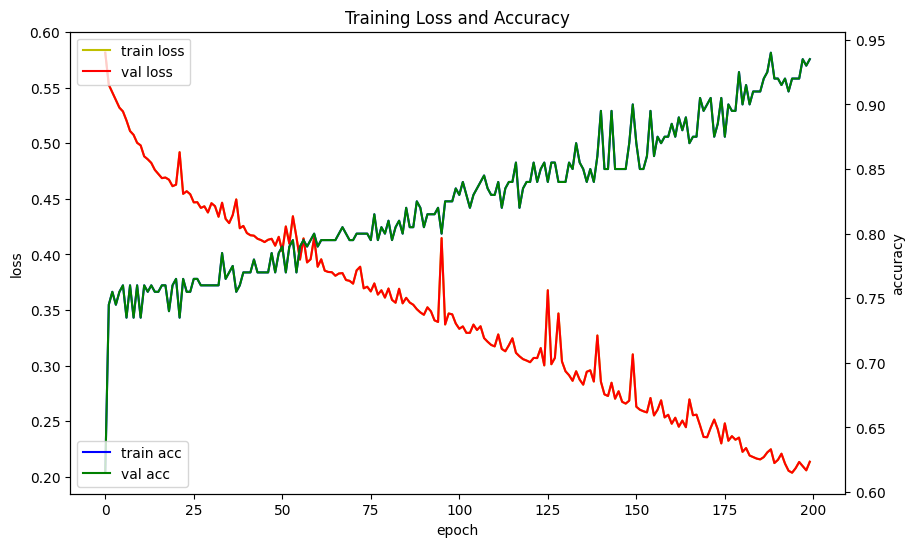

In [10]:
# 그래프를 그릴 기본 Figure와 첫 번째 축을 생성합니다.
fig, loss_ax = plt.subplots(figsize=(10, 6))

# 같은 x축을 공유하면서 오른쪽 y축을 사용할 두 번째 축을 생성합니다.
acc_ax = loss_ax.twinx()

# 훈련 손실값 변화를 노란색 선으로 그립니다.
loss_ax.plot(train_losses, 'y', label='train loss')

# 검증 손실값 변화를 빨간색 선으로 그립니다.
loss_ax.plot(val_losses, 'r', label='val loss')

# 훈련 정확도 변화를 파란색 선으로 그립니다.
acc_ax.plot(train_accuracies, 'b', label='train acc')

# 검증 정확도 변화를 초록색 선으로 그립니다.
acc_ax.plot(val_accuracies, 'g', label='val acc')

# x축 이름을 epoch로 설정합니다.
loss_ax.set_xlabel('epoch')

# 왼쪽 y축 이름을 loss로 설정합니다.
loss_ax.set_ylabel('loss')

# 오른쪽 y축 이름을 accuracy로 설정합니다.
acc_ax.set_ylabel('accuracy')

# 손실률 그래프의 범례 위치를 왼쪽 위로 설정합니다.
loss_ax.legend(loc='upper left')

# 정확도 그래프의 범례 위치를 왼쪽 아래로 설정합니다.
acc_ax.legend(loc='lower left')

# 그래프 제목을 설정합니다.
plt.title('Training Loss and Accuracy')

# 그래프를 화면에 출력합니다.
plt.show()


## 10. 테스트 데이터로 모델 평가하기

테스트 데이터 20개를 대상으로 손실률과 정확도를 계산합니다.


In [11]:
# 평가 단계에서는 기울기 계산이 필요하지 않으므로 torch.no_grad()를 사용합니다.
with torch.no_grad():
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 테스트 데이터에 대한 모델 출력 logit을 계산합니다.
    test_logits = model(X_test)

    # 테스트 손실값을 계산합니다.
    test_loss = criterion(test_logits, Y_test).item()

    # 테스트 정확도를 계산합니다.
    test_acc = calculate_accuracy(test_logits, Y_test).item()

# 테스트 손실값을 출력합니다.
print(f"test loss: {test_loss:.4f}")

# 테스트 정확도를 원본 코드처럼 퍼센트로 출력합니다.
print(f"accuracy: {test_acc * 100:.2f}%")


test loss: 0.2804
accuracy: 90.00%


## 11. 새로운 과일 데이터 예측하기

훈련 데이터의 크기 범위는 대략 1~20인데, 새 데이터의 크기는 45~80입니다.  
따라서 학습 데이터 분포와 차이가 크기 때문에 예측 결과가 불안정할 수 있습니다.


In [12]:
# 새롭게 예측해 볼 과일 데이터를 NumPy 배열로 생성합니다.
# 각 행은 [크기, 무게]를 의미합니다.
new_fruits_np = np.array([
    [50, 150],
    [80, 180],
    [75, 170],
    [60, 150],
    [45, 155]
], dtype=np.float32)

# 비교용 정답 라벨을 만듭니다.
# 1은 오렌지, 0은 귤을 의미합니다.
new_labels_np = np.array([1, 0, 0, 1, 1], dtype=np.float32).reshape(-1, 1)

# NumPy 배열을 PyTorch Tensor로 변환하고 연산 장치로 이동합니다.
new_fruits = torch.tensor(new_fruits_np, dtype=torch.float32).to(device)

# 정답 라벨도 PyTorch Tensor로 변환하고 연산 장치로 이동합니다.
new_labels = torch.tensor(new_labels_np, dtype=torch.float32).to(device)

# 평가 단계에서는 기울기 계산을 하지 않습니다.
with torch.no_grad():
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 새 데이터에 대한 logit을 계산합니다.
    new_logits = model(new_fruits)

    # logit을 sigmoid에 통과시켜 오렌지일 확률을 계산합니다.
    new_probs = torch.sigmoid(new_logits)

    # 확률이 0.5 이상이면 오렌지 1, 그렇지 않으면 귤 0으로 예측합니다.
    new_preds = (new_probs >= 0.5).float()

    # 새 데이터에 대한 정확도를 계산합니다.
    new_acc = (new_preds == new_labels).float().mean().item()

# 각 샘플별 예측 결과를 출력합니다.
for data, prob, pred, label in zip(new_fruits_np, new_probs.cpu().numpy(), new_preds.cpu().numpy(), new_labels_np):
    # 예측 라벨 1은 오렌지, 0은 귤로 표시합니다.
    pred_name = "오렌지" if int(pred[0]) == 1 else "귤"

    # 실제 라벨 1은 오렌지, 0은 귤로 표시합니다.
    label_name = "오렌지" if int(label[0]) == 1 else "귤"

    # 입력값, 오렌지 확률, 예측 결과, 실제 정답을 출력합니다.
    print(f"입력={data.tolist()}, 오렌지 확률={prob[0]:.4f}, 예측={pred_name}, 실제={label_name}")

# 새 데이터 기준 정확도를 출력합니다.
print(f"새 데이터 정확도: {new_acc * 100:.2f}%")


입력=[50.0, 150.0], 오렌지 확률=1.0000, 예측=오렌지, 실제=오렌지
입력=[80.0, 180.0], 오렌지 확률=1.0000, 예측=오렌지, 실제=귤
입력=[75.0, 170.0], 오렌지 확률=1.0000, 예측=오렌지, 실제=귤
입력=[60.0, 150.0], 오렌지 확률=1.0000, 예측=오렌지, 실제=오렌지
입력=[45.0, 155.0], 오렌지 확률=1.0000, 예측=오렌지, 실제=오렌지
새 데이터 정확도: 60.00%
